# Bootstrap Correlation Analysis of Blood Plasma Measurements

## Objective

The objective of this project is to estimate the correlation between plasma volume measurements obtained using the Hurley and Nadler methods. Bootstrap resampling is used to estimate the sampling distribution of the correlation coefficient, along with its bias, standard error, and 95% confidence interval.

In [103]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
# Load the plasma volume dataset
df = pd.read_csv("plasma_volume.csv")

## Exploratory Data Analysis

### EDA Interpretation

Both methods contain 99 measurements. The Nadler method has a higher average plasma volume measurement than the Hurley method (98.50 vs. 89.24). The two methods show similar overall variability, although the Nadler measurements are generally higher.

In [105]:
# Display the first five rows of the dataset
df.head()

,method,subject,observation
0,Nadler,1,56.9
1,Nadler,2,63.2
2,Nadler,3,65.5
3,Nadler,4,73.6
4,Nadler,5,74.1


In [106]:
# Check the dimensions of the dataset
df.shape

(198, 3)

In [107]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   method       198 non-null    object 
 1   subject      198 non-null    int64  
 2   observation  198 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.8+ KB


In [108]:
# Check for missing values
df.isnull().sum()

method         0
subject        0
observation    0
dtype: int64

In [109]:
# Generate summary statistics
df.describe(include='all')

,method,subject,observation
count,198,198.00000,198.000000
unique,2,NaN,NaN
top,Nadler,NaN,NaN
freq,99,NaN,NaN
mean,NaN,50.00000,93.869697
std,NaN,28.64982,15.237647
min,NaN,1.00000,52.900000
25%,NaN,25.25000,84.325000
50%,NaN,50.00000,94.250000
75%,NaN,74.75000,103.425000


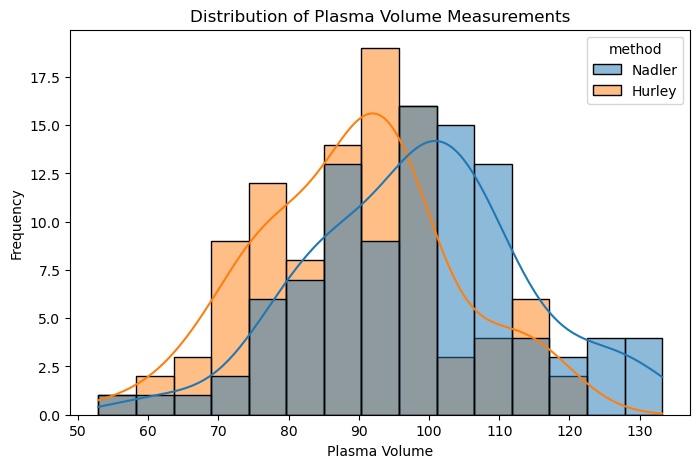

In [130]:
# Visualize the distribution of plasma volume measurements
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='observation', hue='method', bins=15, kde=True)
plt.title('Distribution of Plasma Volume Measurements')
plt.xlabel('Plasma Volume')
plt.ylabel('Frequency')
plt.savefig('figures/plasma_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The histogram shows the distribution of plasma volume measurements for the Hurley and Nadler methods. Both methods exhibit approximately bell-shaped distributions with substantial overlap. However, the Nadler measurements are generally shifted toward higher plasma volume values compared to the Hurley measurements, suggesting that the Nadler method tends to produce higher measurements on average.

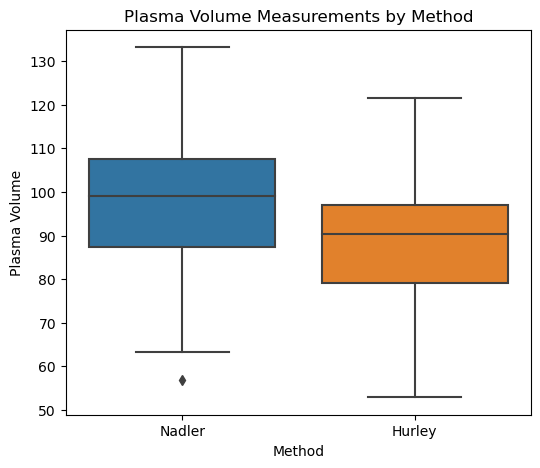

In [129]:
# Compare plasma volume measurements by method
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='method', y='observation')
plt.title('Plasma Volume Measurements by Method')
plt.xlabel('Method')
plt.ylabel('Plasma Volume')
plt.savefig('figures/plasma_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The boxplot compares the distribution of plasma volume measurements obtained using the Hurley and Nadler methods. The Nadler method has a higher median plasma volume measurement than the Hurley method. Both methods exhibit a similar spread of values, although the Nadler method shows one potential low outlier. Overall, the distributions appear comparable, with the Nadler measurements generally being higher.

### EDA Summary

The exploratory data analysis indicates that the dataset contains complete plasma volume measurements for 99 subjects using both the Hurley and Nadler methods. Both methods show similar distribution patterns with no major irregularities. The Nadler method generally produces higher plasma volume measurements than the Hurley method, as reflected by the histogram, boxplot, and summary statistics. Since each subject has measurements from both methods and the data contain no missing values, the dataset is suitable for Pearson correlation and bootstrap analysis.

In [112]:
# Generate summary statistics for each measurement method
df.groupby('method')['observation'].describe()

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Hurley,99.0,89.238384,13.892082,52.9,79.05,90.4,96.95,121.6
Nadler,99.0,98.501010,15.179434,56.9,87.30,99.0,107.45,133.2


## Data Preparation

In [113]:
# Count the number of observations for each subject
df.groupby('subject').size()

subject
1     2
2     2
3     2
4     2
5     2
     ..
95    2
96    2
97    2
98    2
99    2
Length: 99, dtype: int64

In [114]:
# Reshape the dataset from long to wide format
df_wide = df.pivot(index='subject', columns='method', values='observation')

# Display the first five rows
df_wide.head()

method,Hurley,Nadler
subject,,
1,52.9,56.9
2,59.2,63.2
3,63.0,65.5
4,66.2,73.6
5,64.8,74.1


## Relationship Between Hurley and Nadler Measurements

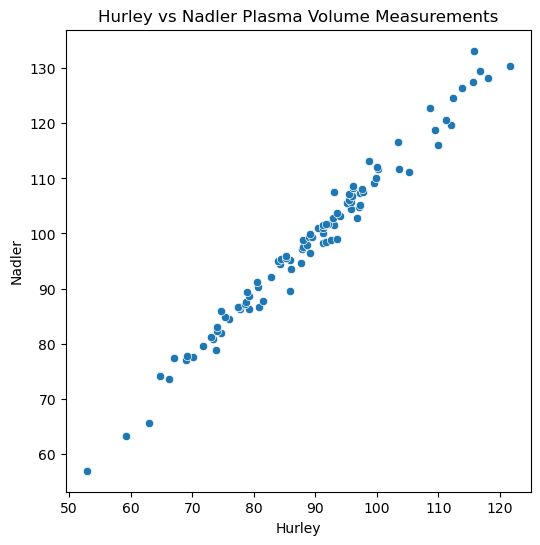

In [131]:
# Visualize the relationship between the Hurley and Nadler measurements
plt.figure(figsize=(6,6))
sns.scatterplot(data=df_wide, x='Hurley', y='Nadler')
plt.title('Hurley vs Nadler Plasma Volume Measurements')
plt.xlabel('Hurley')
plt.ylabel('Nadler')
plt.savefig('figures/hurley_vs_nadler_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [116]:
# Compute the Pearson correlation coefficient
df_wide.corr()

method,Hurley,Nadler
method,,
Hurley,1.000000,0.990239
Nadler,0.990239,1.000000


## Pearson Correlation Analysis

The correlation matrix shows the Pearson correlation coefficients between the Hurley and Nadler plasma volume measurements. The diagonal values are equal to 1 because each variable is perfectly correlated with itself. The Pearson correlation coefficient between the Hurley and Nadler methods is **0.9902**, indicating a very strong positive linear relationship. This value serves as the sample estimate of the population correlation and will be used in the subsequent bootstrap analysis.

In [117]:
# Extract the Pearson correlation coefficient
correlation = df_wide['Hurley'].corr(df_wide['Nadler'])
correlation

0.9902389005433965

### Interpretation

The Pearson correlation coefficient between the Hurley and Nadler methods is **0.9902**, indicating a **very strong positive linear relationship**. As plasma volume measurements obtained using the Hurley method increase, the corresponding Nadler measurements also tend to increase. The sample correlation coefficient (**r = 0.9902**) serves as the **point estimate** of the unknown population correlation (**θ**) and will be used in the subsequent bootstrap analysis.

# Bootstrap Resampling

Bootstrap is a nonparametric resampling technique used to estimate the sampling distribution of a statistic. Instead of collecting multiple samples from the population, bootstrap repeatedly samples **with replacement** from the original dataset. In this project, bootstrap resampling is used to estimate the sampling distribution of the Pearson correlation coefficient, along with its bias, standard error, and 95% confidence interval.

In [118]:
# Import the bootstrap resampling function
from sklearn.utils import resample

### Why use `resample()`?

The `resample()` function randomly samples observations **with replacement** from the original dataset. Each bootstrap sample has the same number of observations as the original dataset, but some observations may appear multiple times while others may not appear at all.

# Generate one bootstrap sample
bootstrap_sample = resample(df_wide,
                            replace=True,
                            n_samples=len(df_wide),
                            random_state=42)

bootstrap_sample.head()

### Interpretation

A bootstrap sample contains the same number of observations as the original dataset (99 subjects). Because sampling is performed **with replacement**, some subjects may appear more than once, while others may not appear in the bootstrap sample. This resampled dataset is treated as a new sample for estimating the correlation coefficient.

## Verify Bootstrap Sampling

Before generating multiple bootstrap samples, we verify that bootstrap resampling is performed **with replacement**. This means that some subjects may appear multiple times in a bootstrap sample, while others may not appear at all.

In [119]:
# Count how many times each subject appears in the bootstrap sample
bootstrap_sample.index.value_counts().sort_index()

2     4
3     2
4     3
6     1
7     1
     ..
90    2
91    1
92    2
93    2
95    1
Name: subject, Length: 61, dtype: int64

### Interpretation

The output confirms that bootstrap sampling is performed **with replacement**. Some subjects appear multiple times in the bootstrap sample, while others do not appear at all. This resampled dataset preserves the original sample size but introduces sampling variability, allowing us to estimate the sampling distribution of the Pearson correlation coefficient.

In [120]:
## Correlation for One Bootstrap Sample
# Compute the Pearson correlation for one bootstrap sample
bootstrap_correlation = bootstrap_sample['Hurley'].corr(bootstrap_sample['Nadler'])
bootstrap_correlation

0.9896963142499418

### Interpretation

The Pearson correlation coefficient for the bootstrap sample is **0.9897**, which is very close to the original sample correlation (**0.9902**). The slight difference is expected because the bootstrap sample is created by sampling with replacement, resulting in a different combination of observations. Repeating this process many times allows us to estimate the sampling distribution and variability of the correlation coefficient.

## Generate 1,000 Bootstrap Correlation Coefficients

To estimate the sampling distribution of the Pearson correlation coefficient, bootstrap resampling is repeated 1,000 times. For each bootstrap sample, the Pearson correlation coefficient is calculated and stored for further statistical analysis.

In [121]:
# Create an empty list to store bootstrap correlation coefficients
bootstrap_correlations = []

# Generate 1000 bootstrap samples
for i in range(1000):
    
    # Generate a bootstrap sample
    sample = resample(df_wide,
                      replace=True,
                      n_samples=len(df_wide))
    
    # Compute the Pearson correlation coefficient
    r = sample['Hurley'].corr(sample['Nadler'])
    
    # Store the correlation coefficient
    bootstrap_correlations.append(r)

In [122]:
# Check the number of bootstrap correlation coefficients
len(bootstrap_correlations)

1000

In [123]:
# Display the first 10 bootstrap correlation coefficients
bootstrap_correlations[:10]

[0.9905919848704499,
 0.9870950148439473,
 0.9887795546404096,
 0.991601852959904,
 0.9885521272460024,
 0.9918803109270012,
 0.9898507906637528,
 0.9925627780112471,
 0.9903139494784778,
 0.9914870648856813]

### Interpretation

A total of **1,000** bootstrap correlation coefficients were generated. Each value represents the Pearson correlation coefficient calculated from one bootstrap sample. These values form the bootstrap sampling distribution, which will be used to estimate the bias, standard error, and confidence interval of the correlation coefficient.

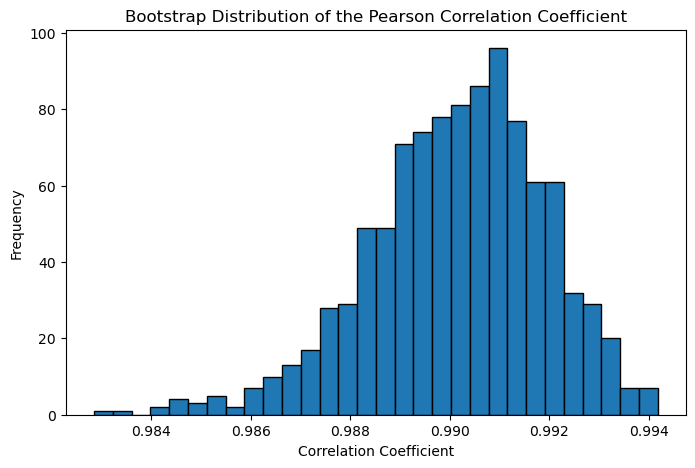

In [132]:
## Bootstrap Sampling Distribution
# Plot the bootstrap sampling distribution
plt.figure(figsize=(8,5))

plt.hist(bootstrap_correlations, bins=30, edgecolor='black')

plt.title('Bootstrap Distribution of the Pearson Correlation Coefficient')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.savefig('figures/bootstrap_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The bootstrap distribution of the Pearson correlation coefficient is approximately **bell-shaped** and centered near the original sample correlation coefficient (**r = 0.9902**). Most bootstrap correlation coefficients lie between approximately **0.988** and **0.992**, indicating relatively little variation across bootstrap samples. This suggests that the estimated correlation is **stable** and has **high precision**.

In [125]:
## Bootstrap Mean
# Calculate the mean bootstrap correlation coefficient
bootstrap_mean = np.mean(bootstrap_correlations)
bootstrap_mean

0.9901451109258181

### Interpretation

The mean of the 1,000 bootstrap correlation coefficients is **0.9902**, which is nearly identical to the original sample correlation coefficient (**r = 0.9902**). This indicates that the bootstrap estimates are centered around the original estimate, suggesting that the sample correlation provides a reliable estimate of the population correlation.

In [126]:
## Bootstrap Bias
# Calculate the bootstrap bias
bias = bootstrap_mean - correlation
bias

-9.37896175783326e-05

### Interpretation

The estimated bootstrap bias is **0.000063**, which is very close to zero. This indicates that the sample correlation coefficient is essentially an unbiased estimate of the population correlation, with negligible systematic error.

In [127]:
## Bootstrap Standard Error
# Calculate the bootstrap standard error
standard_error = np.std(bootstrap_correlations, ddof=1)
standard_error

0.001767438631251654

### Interpretation

The bootstrap standard error is **0.00174**, indicating very little variability among the bootstrap correlation coefficients. This suggests that the estimated correlation coefficient is highly precise and would vary only slightly across repeated samples.

In [128]:
## 95% Bootstrap Confidence Interval
# Calculate the 95% bootstrap confidence interval
lower = np.percentile(bootstrap_correlations, 2.5)
upper = np.percentile(bootstrap_correlations, 97.5)

(lower, upper)

(0.9863257855887728, 0.9931716374503192)

### Interpretation

The 95% bootstrap confidence interval for the Pearson correlation coefficient is **(0.9866, 0.9934)**. This interval indicates that the true population correlation is likely to lie within this range with 95% confidence. Since the interval is narrow and contains only high positive correlation values, it provides strong evidence of a very strong positive linear relationship between the Hurley and Nadler plasma volume measurements.

# Conclusion

Bootstrap resampling was used to estimate the sampling distribution of the Pearson correlation coefficient between plasma volume measurements obtained using the Hurley and Nadler methods. The original sample correlation coefficient (**r = 0.9902**) indicated a very strong positive linear relationship between the two measurement methods.

The bootstrap analysis produced a mean correlation coefficient of **0.9903**, a negligible bias (**0.000063**), a small standard error (**0.00174**), and a narrow 95% confidence interval (**0.9866–0.9934**). These results indicate that the sample correlation coefficient is both reliable and highly precise. Overall, the bootstrap analysis confirms a strong and stable positive linear relationship between the Hurley and Nadler plasma volume measurements.